**Import Libraries**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

**Load Dataset**

In [57]:
df = pd.read_csv("employee_turnover.csv")

In [58]:
df.head()
df.columns
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [59]:
x = df.drop("Employee_Turnover",axis = 1)

In [60]:
y = df["Employee_Turnover"]

**EDA**

Text(0.5, 1.0, 'Employee Turnover Distribution')

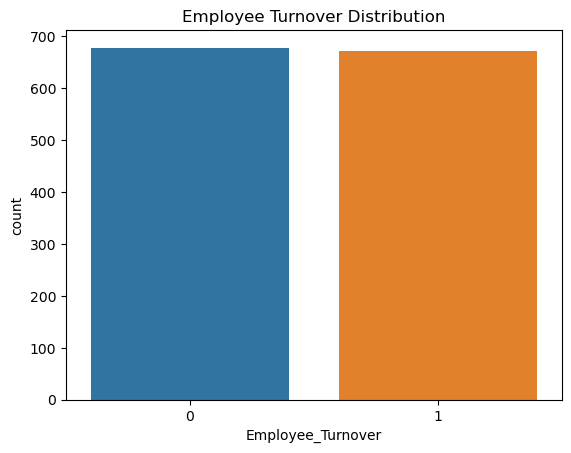

In [61]:
sns.countplot(x="Employee_Turnover", data=df)
plt.title("Employee Turnover Distribution")

Text(0.5, 1.0, 'Correlation Heatmap')

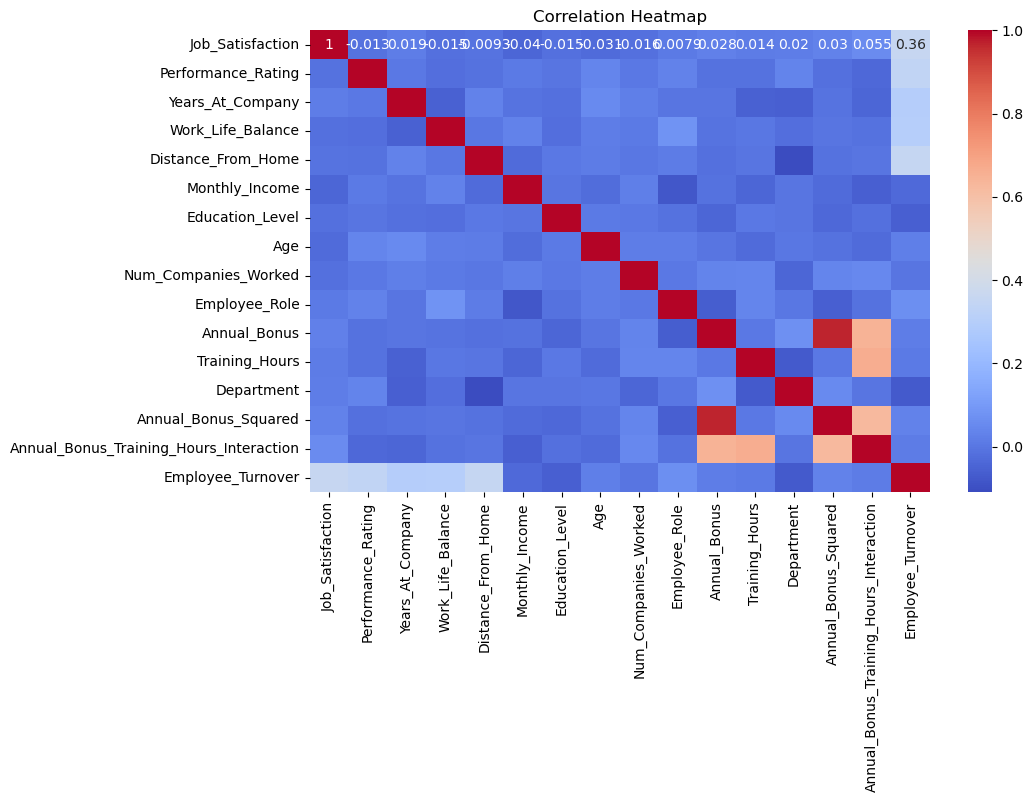

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include = np.number).corr(),annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

**Encoding**

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [64]:
x.head()
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Employee_Turnover, dtype: int64

**Train Test Split**

In [65]:
x_train,x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Scaling**

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Model Training Using KNN**

In [92]:
neighbors = range(1, 15)
train_acc = []
test_acc = []

for k in neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    
    train_acc.append(model.score(x_train_scaled, y_train))
    test_acc.append(model.score(x_test_scaled, y_test))

Text(0.5, 1.0, 'KNN Accuracy vs K')

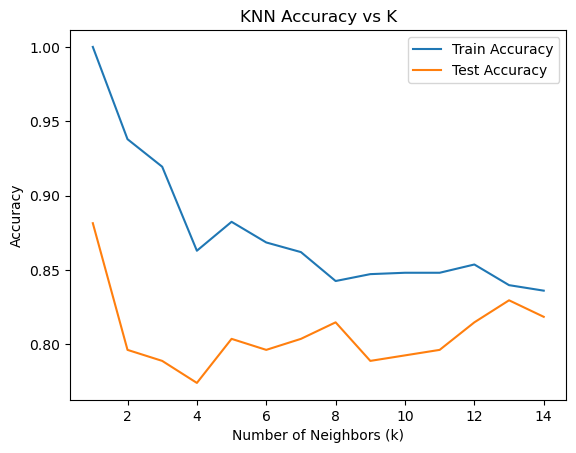

In [93]:
plt.plot(neighbors, train_acc, label="Train Accuracy")
plt.plot(neighbors, test_acc, label="Test Accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.title("KNN Accuracy vs K")

In [94]:
y_pred = model.predict(x_test_scaled)

**Evaluation**

In [97]:
acc = print("accuracy_score",accuracy_score(y_test, y_pred))
acc = print("precision_score",precision_score(y_test, y_pred))
acc = print("recall_score",recall_score(y_test, y_pred))
acc = print("confusion_matrix",confusion_matrix(y_test, y_pred))

accuracy_score 0.8185185185185185
precision_score 0.8725490196078431
recall_score 0.712
confusion_matrix [[132  13]
 [ 36  89]]


**Conclusion**
The KNN model performed best at k = 8, indicating an optimal balance between bias and variance. Lower values of k resulted in overfitting, while higher values led to underfitting. This demonstrates the importance of hyperparameter tuning in improving model performance.